# Yearly Temperature Analysis

Here we'll analyze the yearly temperature trends. At the end of this 
notebook we should have a dataset that should look something like

year | average temperature for that year

In [200]:
# Import pandas
import pandas as pd

# Read main csv file
df = pd.read_csv("../dataset/weather_clean.csv")

We only care about the year and the mean temperature, so we can filter the rest out

In [201]:
df = df[["Year", "Mean Temperature (°C)", "Maximum Temperature (°C)", "Minimum Temperature (°C)"]]

Okay so we need to loop for every year (1983-2019). That would mean taking the base year value and adding +1 about 36 times to get every year. Since there needs to be a really big for loop, the best strategy is breaking this down into **functions**.

For loop (looping 36 times):

* Increment base year value by loop value
* Filter out so only the values of that year are given (function: filter_year)
* Get the mean of the mean temperatures (function: mean_temp)
* Now you have a single value which you can add to an empty dataset for year, mean_temp

In [202]:
# Function to filter out the year
def filter_year(df_, year):
    return df_[df_["Year"] == year]

In [203]:
# Function getting the mean of the mean temperatures
def mean_temp(df_, col):
    return df_[col].mean()

Setting base year and loop amount

In [204]:
base_year = 1983
count = 37

Now for the main for loop

In [205]:
# We wil save the data to an empty list temporarily
yearly_data_list = []

# Main for loop
for i in range(count):
    # Increment to get the current year
    year = base_year + i

    # Filter dataset function to only get that year
    df_filtered = filter_year(df, year)

    # Get the mean temperature for all the mean temperatures of the values
    mean_mean_temp = mean_temp(df_filtered, "Mean Temperature (°C)")

    # Get the minimum temperature
    mean_min_temp = mean_temp(df_filtered, "Minimum Temperature (°C)")

    # Get the maximum temperature
    mean_max_temp = mean_temp(df_filtered, "Maximum Temperature (°C)")

    # Append data to the list
    yearly_data_list.append(
        {"Year": year,
         "Mean Mean Temperature (°C)": mean_mean_temp,
         "Mean Maximum Temperature (°C)": mean_max_temp,
         "Mean Minimum Temperature (°C)": mean_min_temp,
         }
        )


Now we convert this into a dataframe that we can write as a file

In [206]:
# Convert to dataframe
df_yearly_summary = pd.DataFrame(yearly_data_list)

# Write file
df_yearly_summary.to_csv("../dataset/temperature_yearly_summary.csv", index=False)

## Creating graphs

Now we need to understand the data. First I want to see if the temperature is consistently increasing (hence an argument for warming)

### Regression Plot

In [207]:
# Import Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

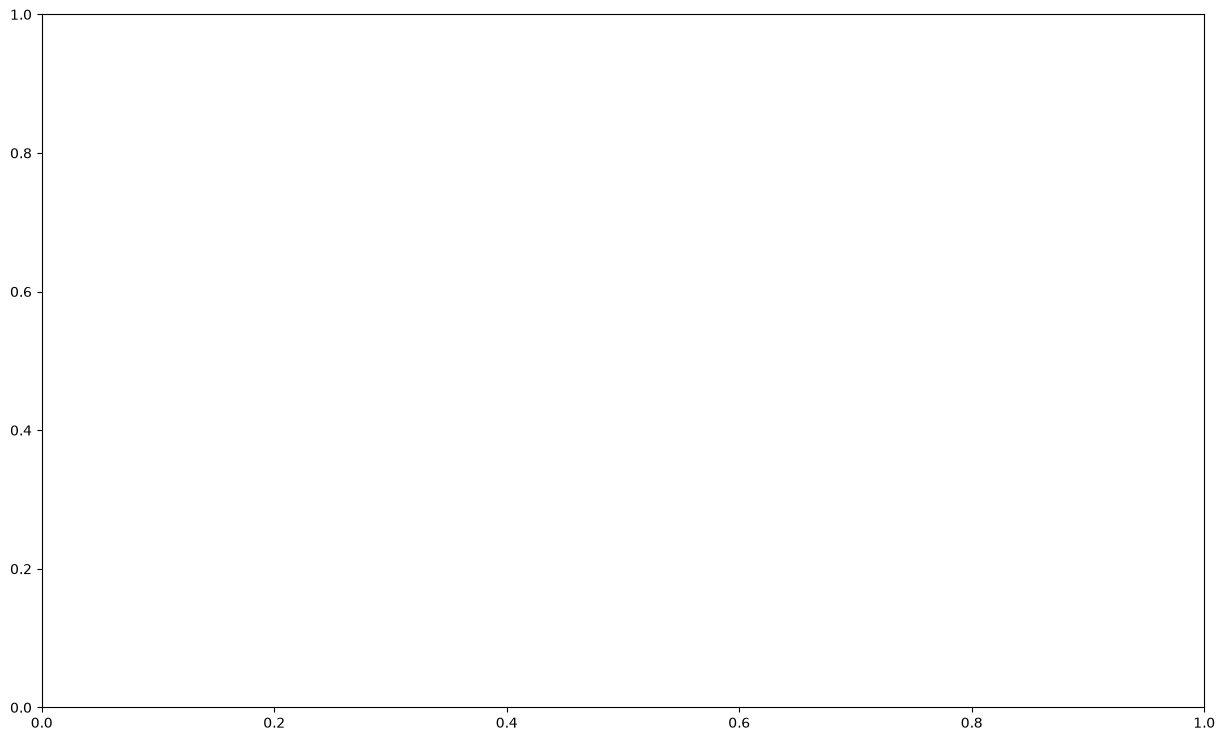

In [208]:
# Create the matplotlib figure
fig, ax = plt.subplots(figsize=(15,9))

In [209]:
# Plotting the graph
sns.regplot(
    data=df_yearly_summary,
    x="Year",
    y="Mean Mean Temperature (°C)",
    color="#ca5506",
    marker="o",
    scatter_kws={"s": 40},
    ax=ax
)

<Axes: xlabel='Year', ylabel='Mean Mean Temperature (°C)'>

In [210]:
# Changing the charts
ax.set_title("Temperature Trajectory (1983-2019)", fontsize=16, pad=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Mean Temperature (°C)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

In [211]:
# Save figure
fig.savefig(fname="../media/regression_plot_summary.png", format="png", dpi=300, bbox_inches="tight")

### Yearly Temperature Range Area Chart


Okay now I want to do something more advance. I'll use the Maximum and Minimum Temperature values and create an area chart

In [212]:
# Plotting the upper and lower bounds
ax.plot(df_yearly_summary["Year"], df_yearly_summary["Mean Maximum Temperature (°C)"], color="#e74c3c", alpha=0.5, label="Max Temp")
ax.plot(df_yearly_summary["Year"], df_yearly_summary["Mean Minimum Temperature (°C)"], color="#3498db", alpha=0.5, label="Min Temp")

In [213]:
# Fil the space b/w the data
ax.fill_between(
    df_yearly_summary["Year"],
    df_yearly_summary["Mean Minimum Temperature (°C)"],
    df_yearly_summary["Mean Maximum Temperature (°C)"],
    color="#95a5a6",
    alpha=0.2,
    label="Yearly Range"
)

In [214]:
# Plotting the graph
ax.plot(df_yearly_summary["Year"], df_yearly_summary["Mean Mean Temperature (°C)"], color="#2c3e50", linewidth=2, label="Mean Temp")

In [215]:
# Setting graph characteristics
ax.set_title("Yearly Temperature Envelope (Range & Mean)", fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Year")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend

<bound method Axes.legend of <Axes: title={'center': 'Yearly Temperature Envelope (Range & Mean)'}, xlabel='Year', ylabel='Temperature (°C)'>>

In [216]:
# Save the plot
fig.savefig(fname="../media/yearly_temp_range_chart.png", format="png", dpi=300, bbox_inches="tight")